# Image classification models
## Dependencies

In [ ]:
%%capture
!cmd /c dependencies.bat

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import random
from collections import defaultdict
import pickle

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
random.seed(42)

## Data


In [10]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [11]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']


In [12]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path)

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [13]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007


## Auxiliary functions

In [14]:
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(256, 256))  
    img = image.img_to_array(img)  # (256, 256, 3)
    img = img / 255.0  
    return img

In [15]:
def prepareData(df):

    # Filtrar filas válidas (si hay imágenes faltantes)
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()

    # Cargar imágenes y etiquetas
    images = []
    labels = []
    image_names = []

    for _, row in df_valid.iterrows():
        img_path = row['full_path']
        label = row['label']

        session_dir = os.path.dirname(img_path)                 
        session_name = os.path.basename(os.path.normpath(session_dir))  

        file_name_without_ext = os.path.splitext(os.path.basename(img_path))[0]

        relative_id = f"{session_name}\\{file_name_without_ext}"

        image_names.append(relative_id)

        # Cargar y preprocesar imagen
        img = load_and_preprocess(img_path)  # Usa la función existente
        images.append(img)
        labels.append(label)

    # Convertir a arrays de NumPy
    images = np.array(images)  # Forma: (num_samples, 256, 256, 3)
    labels = np.array(labels)  # Forma: (num_samples,)
    image_names = np.array(image_names)

    print(f"Total de imágenes cargadas: {len(images)}")
    print(f"Forma de images: {images.shape}")
    print(f"Forma de labels: {labels.shape}")

    # Dividir en train y test (80% train, 20% test)
    train_images, test_images, train_labels, test_labels, train_names, test_names = \
        train_test_split(
            images, labels, image_names,
            test_size=0.2,
            random_state=42,
            stratify=labels
        )

    return train_images, test_images, train_labels, test_labels, train_names, test_names

In [16]:
def encode_labels(train_labels, test_labels):
    mapa = {
        "colocarPila": 0,
        "colocarSoporteSup": 1,
        "colocarNiquel": 2,
        "soldar": 3
    }

    mapa_inverso = {v: k for k, v in mapa.items()}

    train_labels_encoded = np.array([mapa[x] for x in train_labels])
    test_labels_encoded = np.array([mapa[x] for x in test_labels])
    
    return train_labels_encoded, test_labels_encoded

In [18]:
def show_image_and_label(images, labels, image_names, num_images=20):
  
    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"{name}\n{labels[i]}"
        
        plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

In [19]:
def plot_from_history(history, epochs):

    # Manejar tanto objeto history como dict directamente
    if hasattr(history, 'history'):
        hist = history.history
    else:
        hist = history

    acc = hist['accuracy']
    val_acc = hist['val_accuracy']

    loss = hist['loss']
    val_loss = hist['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [20]:
def save_history(history, nombre_archivo):
    with open(nombre_archivo, "wb") as f:
        pickle.dump(history.history, f)

def load_history(nombre_archivo):
    if os.path.exists(nombre_archivo):
        with open(nombre_archivo, "rb") as f:
            loaded_history = pickle.load(f)
        print(f"Historial cargado desde {nombre_archivo}.")
        return loaded_history
    else:
        print(f"No se encontró el archivo {nombre_archivo}.")
        return None

In [21]:
def training_pipeline(model, train_images, train_labels_encoded, test_images, test_labels_encoded, epochs=10, validation_split=0.2, lr=0.005):

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',   factor=0.5,  patience=7,verbose=1, min_lr=4e-10
    )

    model.compile(optimizer=optimizer,
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])
    
    history = model.fit(train_images, train_labels_encoded,epochs=epochs,batch_size = 32,validation_split=validation_split,callbacks = [lr_callback])

    train_loss, train_acc = model.evaluate(train_images,  train_labels_encoded, verbose=2)
    test_loss, test_acc = model.evaluate(test_images,  test_labels_encoded, verbose=2)
    
    return test_acc, train_acc, history

## Get dataset

In [22]:
train_images, test_images, train_labels, test_labels, train_names, test_names = prepareData(df)

print(f"Train images: {train_images.shape}, Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}, Test labels: {test_labels.shape}")


train_labels_encoded, test_labels_encoded = encode_labels(train_labels, test_labels)

Total de imágenes cargadas: 2108
Forma de images: (2108, 256, 256, 3)
Forma de labels: (2108,)
Train images: (1686, 256, 256, 3), Train labels: (1686,)
Test images: (422, 256, 256, 3), Test labels: (422,)


## Baseline models

### ResNet50 - Tensorflow

In [23]:
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

ResNet50 sin pesos preentrenados

In [25]:
base_resnet50 = ResNet50(
    weights = None,
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3)  # if include_top true input shape must be (224, 224, 3) 
)

model_resnet50 = Sequential([
    base_resnet50,
    layers.GlobalAveragePooling2D(),        # mapa 4D a vector 2D
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_resnet50, train_acc_resnet50, history_resnet50 = training_pipeline(model_resnet50, train_images, train_labels_encoded, test_images, test_labels_encoded, epochs = epochs)
print(f"Test accuracy: {test_acc_resnet50}\nTrain accuracy: {train_acc_resnet50}")


Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 389s 8s/step - accuracy: 0.7151 - loss: 1.2311 - val_accuracy: 0.4527 - val_loss: 102917088.0000 - learning_rate: 0.0050
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 344s 8s/step - accuracy: 0.8687 - loss: 0.3861 - val_accuracy: 0.4527 - val_loss: 26706.6797 - learning_rate: 0.0050
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 344s 8s/step - accuracy: 0.8961 - loss: 0.3144 - val_accuracy: 0.4527 - val_loss: 7621.5864 - learning_rate: 0.0050
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 343s 8s/step - accuracy: 0.9332 - loss: 0.2078 - val_accuracy: 0.1006 - val_loss: 1895.3374 - learning_rate: 0.0050
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 359s 8s/step - accuracy: 0.9013 - loss: 0.3934 - val_accuracy: 0.4527 - val_loss: 1408.2810 - learning_rate: 0.0050
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 346s 8s/step - accuracy: 0.8835 - loss: 0.7534 - val_accuracy: 0.3994 - val_loss: 22708.2637 - learning_rate: 0.0050
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 350s 8s/step - accuracy: 0.7856

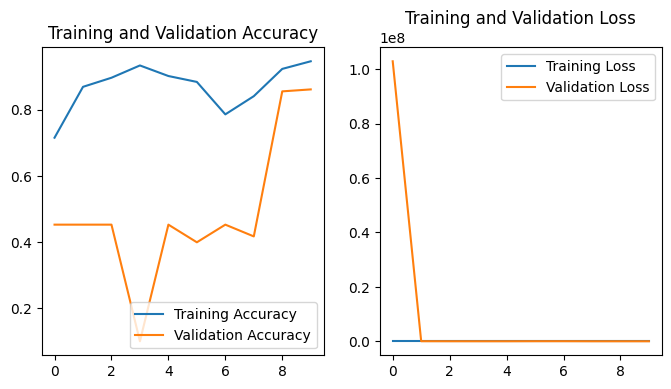

In [26]:
plot_from_history(history_resnet50, epochs = epochs)

#### Save model

In [27]:
model_resnet50.save("modelo_clas_proc_resnet50.keras")
save_history(history_resnet50, "history_resnet50.pkl")


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



#### Load model

In [ ]:
model_resnet50 = load_model("modelo_clas_proc_resnet50.keras")
history_resnet50 = load_history("history_resnet50.pkl")

#### Test

In [ ]:
y_pred_resnet50 = model_resnet50.predict(test_images)

y_pred_classes_resnet50 = y_pred_resnet50.argmax(axis=1)

f1_resnet50 = f1_score(test_labels_encoded, y_pred_classes_resnet50, average="weighted")
print(f"F1 Score ResNet50: {f1_resnet50}")
print("-------------------------------------")

cm = multilabel_confusion_matrix(test_labels_encoded, y_pred_classes_resnet50)
print("Confusion Matrix ResNet50:")
for i, matrix in enumerate(cm):
    print(f"Clase {i}:\n{matrix}\n")
print("-------------------------------------")

print("Classification Report ResNet50:")
print(classification_report(test_labels_encoded, y_pred_classes_resnet50, target_names=["colocarPila", "colocarSoporteSup", "colocarNiquel", "soldar"]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
F1 Score ResNet50: 0.7498212627549481
-------------------------------------
Confusion Matrix ResNet50:
Clase 0:
[[195  61]
 [  0 166]]

Clase 1:
[[409   0]
 [ 13   0]]

Clase 2:
[[362   2]
 [ 58   0]]

Clase 3:
[[224  13]
 [  5 180]]

-------------------------------------
Classification Report ResNet50:
                   precision    recall  f1-score   support

      colocarPila       0.73      1.00      0.84       166
colocarSoporteSup       0.00      0.00      0.00        13
    colocarNiquel       0.00      0.00      0.00        58
           soldar       0.93      0.97      0.95       185

         accuracy                           0.82       422
        macro avg       0.42      0.49      0.45       422
     weighted avg       0.70      0.82      0.75       422



C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

ResNet con pesos entrenados con imageNet

In [ ]:
from tensorflow.keras.applications.resnet import preprocess_input

In [31]:
X_train_processed = preprocess_input(train_images.astype('float32'))
X_test_processed  = preprocess_input(test_images.astype('float32'))

base_resnet50_imgnet = ResNet50(
    weights = "imagenet",
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3)  # if include_top true input shape must be (224, 224, 3) 
)

model_resnet50_imagenet = Sequential([
    base_resnet50_imgnet,
    layers.GlobalAveragePooling2D(),        # mapa 4D a vector 2D
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_resnet50_imgnet, train_acc_resnet50_imgnet, history_resnet50_imgnet = training_pipeline(model_resnet50_imagenet, X_train_processed, train_labels_encoded, X_test_processed, test_labels_encoded, epochs = epochs)
print(f"Test accuracy: {test_acc_resnet50_imgnet}\nTrain accuracy: {train_acc_resnet50_imgnet}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.8435 - loss: 0.7161 - val_accuracy: 0.4172 - val_loss: 35444006912.0000 - learning_rate: 0.0050
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 318s 7s/step - accuracy: 0.9451 - loss: 0.2306 - val_accuracy: 0.4527 - val_loss: 405848.0000 - learning_rate: 0.0050
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 316s 7s/step - accuracy: 0.9488 - loss: 0.1727 - val_accuracy: 0.4527 - val_loss: 49536.2070 - learning_rate: 0.0050
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 316s 7s/step - accuracy: 0.9496 - loss: 0.1597 - val_accuracy: 0.4172 - val_loss: 40.5192 - learning_rate: 0.0050
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 318s 7s/step - accuracy: 0.9562 - loss: 0.1312 - val_accuracy: 0.4527 - val_loss: 1.5712 - learning_rate: 0.0050
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 317s 7s/step - accuracy: 0.9473 - loss: 0.1753 - val_accuracy: 0.4172 - val_loss: 146.7074 - learning_rate: 0.0050
Epoch 7/10
43/43 ━━━

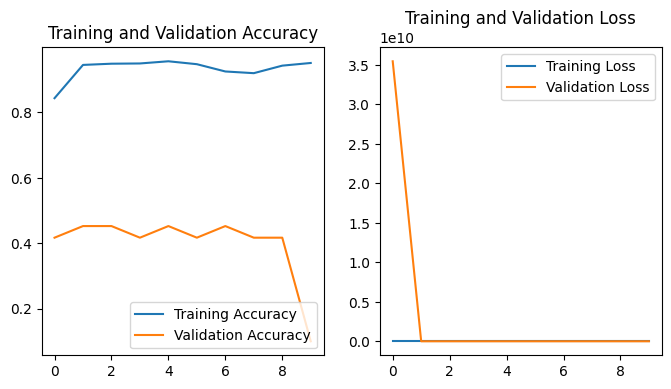

In [32]:
plot_from_history(history_resnet50_imgnet, epochs = epochs)

#### Save model

In [33]:
model_resnet50_imagenet.save("modelo_clas_proc_resnet50_imgnet.keras")
save_history(history_resnet50_imgnet, "history_resnet50_imgnet.pkl")

#### Load model

In [ ]:
model_resnet50_imagenet = load_model("modelo_clas_proc_resnet50_imgnet.keras")
history_resnet50_imgnet = load_history("history_resnet50_imgnet.pkl")

#### Test

In [34]:
y_pred_resnet50_imgnet = model_resnet50_imagenet.predict(test_images)

y_pred_classes_resnet50_imgnet = y_pred_resnet50.argmax(axis=1)

f1_resnet50 = f1_score(test_labels_encoded, y_pred_classes_resnet50_imgnet, average="weighted")
print(f"F1 Score ResNet50: {f1_resnet50}")
print("-------------------------------------")

cm = multilabel_confusion_matrix(test_labels_encoded, y_pred_classes_resnet50_imgnet)
print("Confusion Matrix ResNet50:")
for i, matrix in enumerate(cm):
    print(f"Clase {i}:\n{matrix}\n")
print("-------------------------------------")

print("Classification Report ResNet50:")
print(classification_report(test_labels_encoded, y_pred_classes_resnet50_imgnet, target_names=["colocarPila", "colocarSoporteSup", "colocarNiquel", "soldar"]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
F1 Score ResNet50: 0.7498212627549481
-------------------------------------
Confusion Matrix ResNet50:
Clase 0:
[[195  61]
 [  0 166]]

Clase 1:
[[409   0]
 [ 13   0]]

Clase 2:
[[362   2]
 [ 58   0]]

Clase 3:
[[224  13]
 [  5 180]]

-------------------------------------
Classification Report ResNet50:
                   precision    recall  f1-score   support

      colocarPila       0.73      1.00      0.84       166
colocarSoporteSup       0.00      0.00      0.00        13
    colocarNiquel       0.00      0.00      0.00        58
           soldar       0.93      0.97      0.95       185

         accuracy                           0.82       422
        macro avg       0.42      0.49      0.45       422
     weighted avg       0.70      0.82      0.75       422



C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas